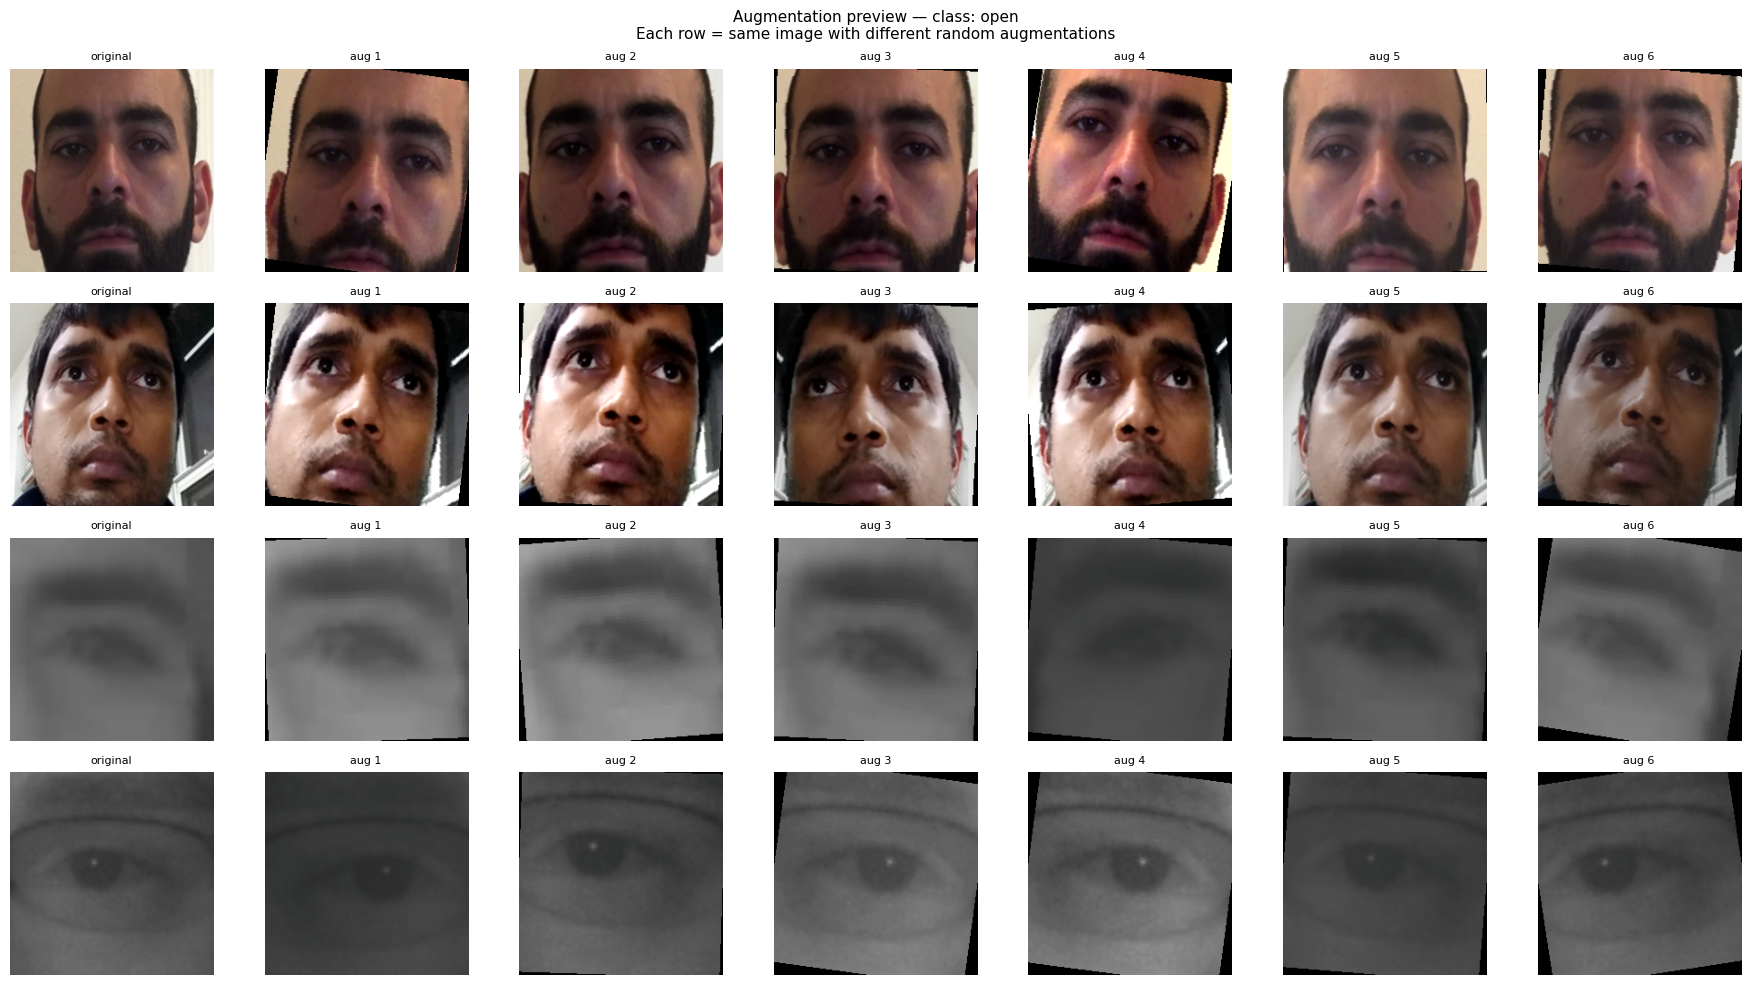

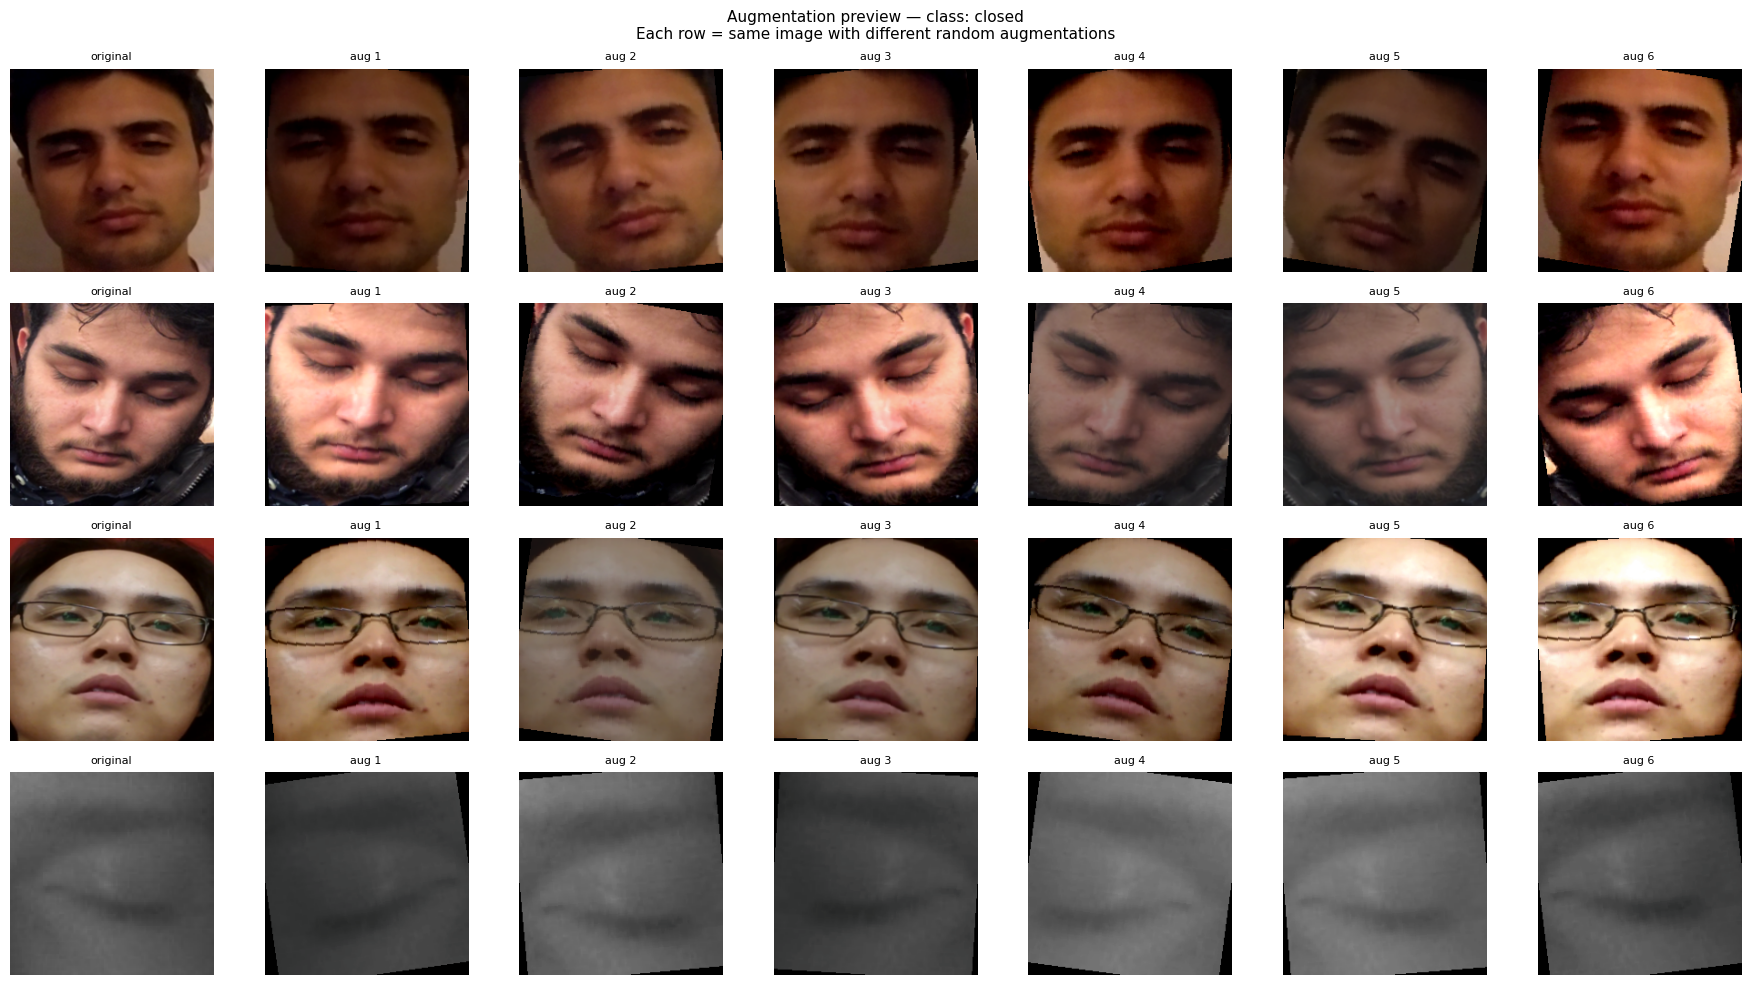

In [5]:
import random, torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from torchvision import transforms

PROCESSED = Path("../data/processed/train")
random.seed(42)

# Your planned training transforms — THESE are what go into dataset.py later
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.1
    ),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    )
])

def unnormalize(t):
    """Convert normalized tensor back to viewable image."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    t    = (t * std + mean).clamp(0, 1)
    return transforms.ToPILImage()(t)

for label in ["open", "closed"]:
    files   = list((PROCESSED / label).iterdir())
    samples = random.sample(files, 4)    # 4 source images
    aug_per = 6                            # augmentations per source

    fig, axes = plt.subplots(4, aug_per+1, figsize=(18, 10))
    border = "#2ecc71" if label=="open" else "#e74c3c"

    for row, fpath in enumerate(samples):
        original = Image.open(fpath).convert("RGB")

        # Column 0 — original
        axes[row, 0].imshow(original)
        axes[row, 0].set_title("original", fontsize=8)
        axes[row, 0].axis("off")

        # Columns 1–6 — different augmentations of same image
        for col in range(1, aug_per+1):
            aug = unnormalize(train_transforms(original))
            axes[row, col].imshow(aug)
            axes[row, col].set_title(f"aug {col}", fontsize=8)
            axes[row, col].axis("off")

    plt.suptitle(
        f"Augmentation preview — class: {label}\n"
        "Each row = same image with different random augmentations",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f"../outputs/augmentation_{label}.png",
                dpi=120, bbox_inches="tight")
    plt.show()
